# Eksperimen_SML Andi-Sakta

**Dataset:** Pima Indians Diabetes (Kaggle)

**Tujuan:** Eksplorasi + EDA + Preprocessing manual per template kriteria 1 MSML.

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Load raw dataset
df = pd.read_csv('../diabetes_raw.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. EDA (Exploratory Data Analysis)

In [2]:
# Informasi kolom & memori
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# Deskriptif statistik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [4]:
# Missing nilai check
print('Missing:')
print(df.isnull().sum())
print('\nDuplicated:', df.duplicated().sum())

Missing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicated: 0


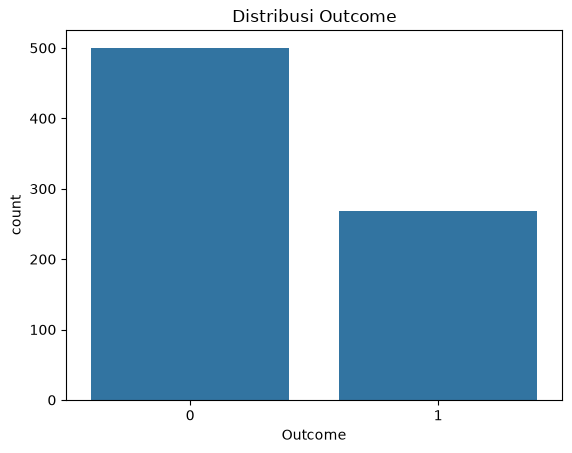

Outcome value counts:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [5]:
# Distribusi target
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome')
plt.show()
print('Outcome value counts:')
print(df['Outcome'].value_counts(normalize=True))

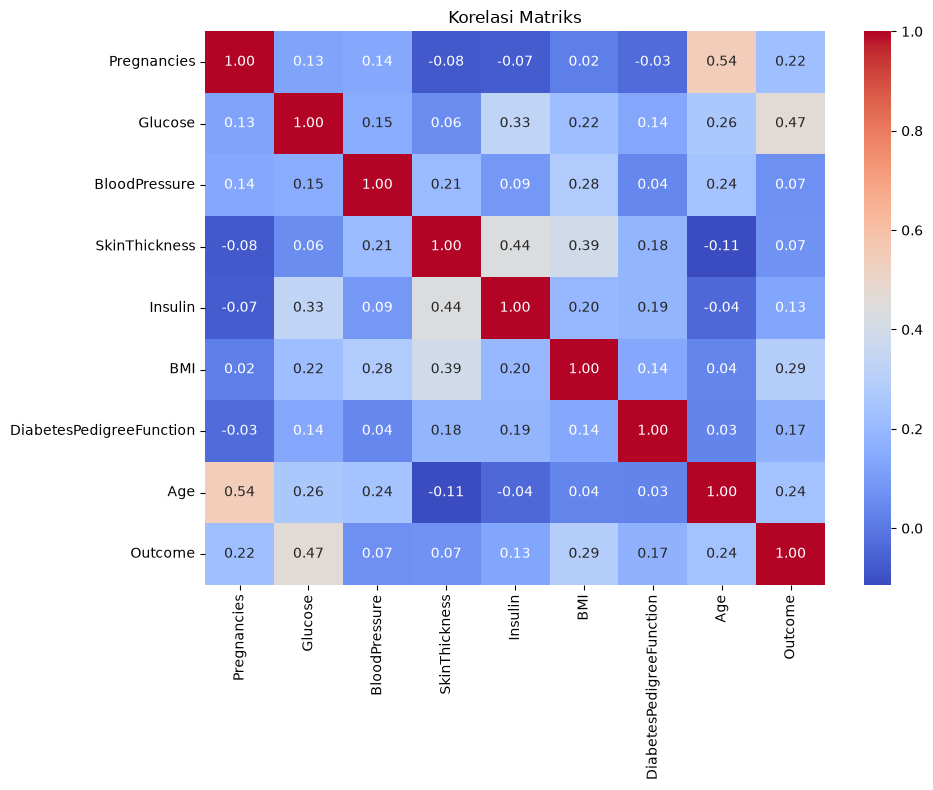

In [6]:
# Korelasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Matriks')
plt.tight_layout()
plt.show()

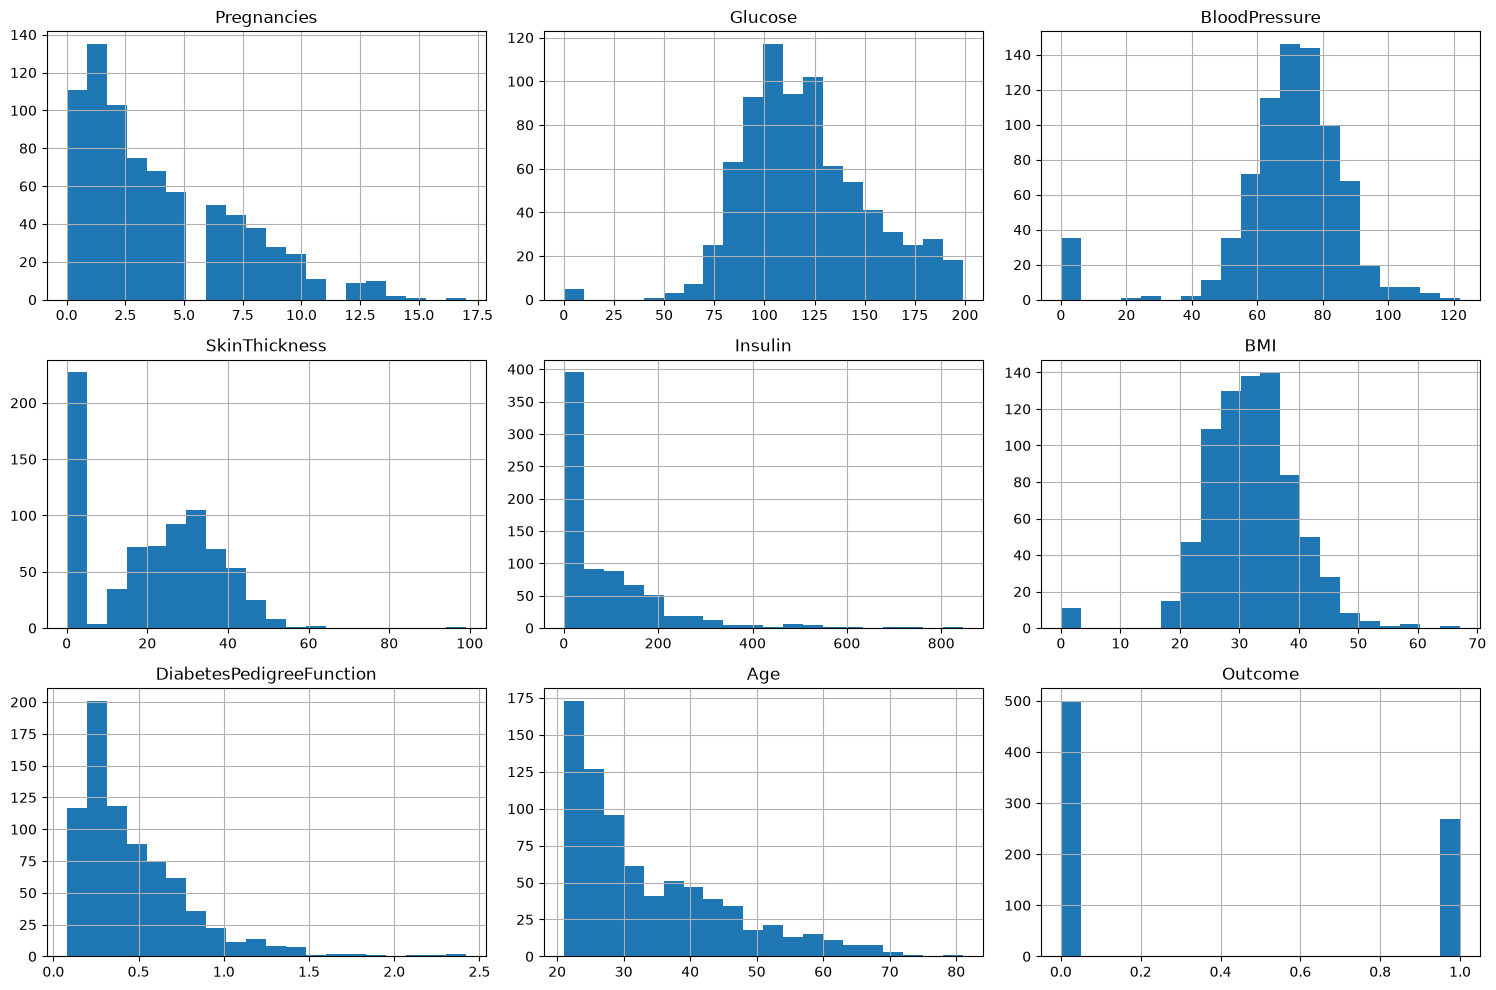

In [7]:
# Distribusi setiap feature
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [8]:
# Boxplot untuk detect outlier: kolom yang bisa berisi nilai 0 bernot meaningful
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Nilai 0 per kolom (bernolung tidak valid):')
for c in cols_with_zero:
    zero_count = (df[c] == 0).sum()
    print(f'  {c}: {zero_count}')

Nilai 0 per kolom (bernolung tidak valid):
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11


## 3. Preprocessing

**Tahap:**
1. Imputasi nilai 0 → NaN → median (kolom Glucose, BloodPressure, SkinThickness, Insulin, BMI)
2. Verifikasi missing cleared
3. Split train/test 80/20 stratify
4. Scaling numeric (StandardScaler, fit on train only)
5. Save hasil

In [9]:
# Tahap 1: Imputasi nilai 0 -> NaN -> median
df_clean = df.copy()
for c in cols_with_zero:
    df_clean[c] = df_clean[c].replace(0, np.nan)
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

print('Missing setelah imputasi:', df_clean.isnull().sum().sum())
print('Nol dan')
df_clean[cols_with_zero].head()

Missing setelah imputasi: 0
Nol dan


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,125.0,33.6
1,85.0,66.0,29.0,125.0,26.6
2,183.0,64.0,29.0,125.0,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1


In [10]:
# Tahap 3: Split train/test
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (614, 8), X_test: (154, 8)


In [11]:
# Tahap 4: StandardScaler fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train_scaled shape:', X_train_scaled.shape)
print('Mean per feature (hampir 0):', X_train_scaled.mean(axis=0).round(2))

X_train_scaled shape: (614, 8)
Mean per feature (hampir 0): [-0. -0.  0. -0. -0. -0. -0. -0.]


In [12]:
# Tahap 5: Save hasil preprocessing (train + test gabung kembali, label split)
train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df['Outcome'] = y_train.values
test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df['Outcome'] = y_test.values

df_preprocessed = pd.concat([train_df, test_df], axis=0)
df_preprocessed.to_csv('diabetes_preprocessing.csv', index=False)
print(f'Saved diabetes_preprocessing.csv shape: {df_preprocessed.shape}')

Saved diabetes_preprocessing.csv shape: (768, 9)


## Konklusi

- Dataset 768 baris, 9 kolom (8 feature + Outcome).
- Preprocessing: imputasi 0→median su 5 kolom, split 80/20 stratified, StandardScaler fit on train.
- Output `diabetes_preprocessing.csv` siap untuk training.